In [ ]:
# all libraries needed to run code
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

## Dataset Prep

In [15]:
# enumerating class labels
classes = ['muscovy', 'mallard', 'wood', 'magpie', 'mandarin', 
           'swedish', 'orpington', 'pekin', 'harlequin', 'merganser']

class_to_index = {c: i for i, c in enumerate(classes)}

In [16]:
# downloading training images
train_path = Path("/Users/taylerraebachmann/Desktop/train")
train_images = []
train_file_names = []

# creating dataset of images and corresponding labels from images for training 
for img_path in train_path.glob("*.jpg"):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((128, 128))          
    train_images.append(np.array(img))
    train_file_names.append(img_path.name)     

# making numpy array for training images and labels
X_train = np.array(train_images, dtype=np.float32) / 255.0
train_labels = [f.split("_")[0] for f in train_file_names]
y_train = np.array([class_to_index[label] for label in train_labels])

In [17]:
# downloading testing images
test_path = Path("/Users/taylerraebachmann/Desktop/test")
test_images = []
test_file_names = []

# creating dataset of images and corresponding labels from images for testing 
for img_path in test_path.glob("*.jpg"):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((128, 128))          
    test_images.append(np.array(img))
    test_file_names.append(img_path.name)     

# making numpy array for testing images and labels
X_test = np.array(test_images, dtype=np.float32) / 255.0
test_labels = [f.split("_")[0] for f in test_file_names]
y_test = np.array([class_to_index[label] for label in test_labels])

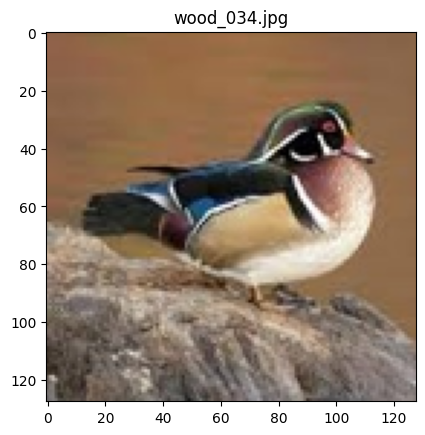

In [18]:
# displaying one image and it's label to make sure they stored properly
plt.imshow(X_test[2])
plt.title(test_file_names[2])
plt.show()

## Model

Using EfficientNetB0 classifier model from keras:
https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0?utm_source=chatgpt.com

In [19]:
# building model

# using EfficientNetB0 backbone because it gave better results than the other two that were tried (ViTImageClassifier and ConvNeXtTiny)
# 128x128 image size is best size to balance accuracy and efficiency
# pre-trained weights trainined on ImageNet also gave significantly better results
backbone = EfficientNetB0(
    include_top=False,        
    input_shape=(128, 128, 3),
    pooling='avg',              
    weights=None              
)

# using softmax output with 10 layers (one for each duck breed) for a classification task
inputs = layers.Input(shape=(128,128,3))
x = backbone(inputs, training=True)
outputs = layers.Dense(10, activation='softmax')(x)  
model = models.Model(inputs, outputs)

# compiling the model with a 3e-4 learning rate, which is suggested for EfficientNetB0
model.compile(
    optimizer = keras.optimizers.Adam(3e-4),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ["accuracy"]
)

In [20]:
# training model on 30 epochs and batch size of 8, which 
model.fit(x=X_train, y=y_train, batch_size=8, epochs=30)
preds = model.predict(X_train)
print(preds)

Epoch 1/30


/Users/taylerraebachmann/Library/Python/3.9/lib/python/site-packages/keras/backend.py:5612: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


100/100 [==============================] - 144s 971ms/step - loss: 2.2939 - accuracy: 0.1725
Epoch 2/30
100/100 [==============================] - 99s 982ms/step - loss: 2.0869 - accuracy: 0.2450
Epoch 3/30
100/100 [==============================] - 97s 970ms/step - loss: 1.9251 - accuracy: 0.3338
Epoch 4/30
100/100 [==============================] - 101s 1s/step - loss: 1.5503 - accuracy: 0.4575
Epoch 5/30
100/100 [==============================] - 108s 1s/step - loss: 1.3499 - accuracy: 0.5213
Epoch 6/30
100/100 [==============================] - 107s 1s/step - loss: 1.0818 - accuracy: 0.6438
Epoch 7/30
100/100 [==============================] - 97s 965ms/step - loss: 0.8764 - accuracy: 0.7050
Epoch 8/30
100/100 [==============================] - 97s 967ms/step - loss: 0.7600 - accuracy: 0.7500
Epoch 9/30
100/100 [==============================] - 92s 924ms/step - loss: 0.7028 - accuracy: 0.7775
Epoch 10/30
100/100 [==============================] - 95s 952ms/step - loss: 0.6083 - ac

In [21]:
# testing model
_, acc = model.evaluate(X_test, y_test)
print('Test Accuracy: %.2f%%' % (acc * 100.0))

7/7 [==============================] - 9s 856ms/step - loss: 2.8883 - accuracy: 0.4000
Test Accuracy: 40.00%
